# Bigger ASR Model Comparison — FIXED
## Models in This Notebook

| # | Model | HuggingFace ID | Params | Bengali | Status |
|---|-------|----------------|--------|---------|--------|
| 1 | Qwen2-Audio 7B | `Qwen/Qwen2-Audio-7B-Instruct` | 7B | ⚠ Exp | **FIXED** — 4-bit quantization |
| 2 | Voxtral-Mini 3B | `mistralai/Voxtral-Mini-3B-2507` | ~4.7B | ⚠ Exp | **NEW** — replaces Canary-1B |
| 3 | Phi-4 Multimodal | `microsoft/phi-4-multimodal-instruct` | 5.6B | ⚠ Exp | **FIXED** — correct audio pipeline |
| 4 | Qwen3-ASR 1.7B | `Qwen/Qwen3-ASR-1.7B` | 1.7B | ❌ None | **FIXED** — runs, outputs Hindi (closest to Bengali) |
| 5 | Qwen2.5-Omni 7B | `Qwen/Qwen2.5-Omni-7B` | 7B | ⚠ Exp | **NEW** — replaces MiMo-Audio (which needed custom framework) |

### Changes from Original
- **Model 1**: Always uses 4-bit quantization (was OOM-ing in float16 on T4)
- **Model 2**: Canary-1B **replaced** with Voxtral-Mini-3B (Canary needs NeMo + no Bengali + only 1B params)
- **Model 3**: Fixed audio input pipeline (`soundfile` + `<|audio_1|>` prompt format)
- **Model 4**: Improved settings (`max_new_tokens=1024`, Hindi fallback language)
- **Model 5**: MiMo-Audio **replaced** with Qwen2.5-Omni-7B (MiMo needed custom framework + too large)


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
ROOT = '/content/drive/MyDrive/CSE499_EHR_Project'
assert os.path.exists(ROOT), f'ERROR: {ROOT} not found.'
print(f'✅ Drive mounted. ROOT = {ROOT}')

Mounted at /content/drive
✅ Drive mounted. ROOT = /content/drive/MyDrive/CSE499_EHR_Project


 Install Libraries

In [ ]:
# ─── Install packages ──────────────────────────────────────────────────────
# DO NOT install nemo_toolkit — it corrupts numpy in Colab.
# Canary-1B (which needs NeMo) has been REPLACED with Voxtral-Mini-3B.

!pip install -q 'transformers>=4.54.0' datasets evaluate jiwer librosa soundfile torch accelerate
!pip install -q sentencepiece protobuf nltk scikit-learn seaborn
!pip install -q bitsandbytes
!pip install -q qwen_asr                          # Qwen3-ASR inference package
!pip install -q 'qwen-omni-utils[decord]'         # Qwen2.5-Omni audio processing
!pip install -q 'mistral-common[audio]>=1.8.1'    # Voxtral audio processing
!pip install -q scipy                             # Phi-4 audio processing

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ─── Numpy sanity check ───────────────────────────────────────────────────
try:
    import numpy as np
    _ = np.array([1, 2, 3])
    print(f'\u2705 All libraries installed. numpy {np.__version__} OK.')
except Exception as e:
    print(f'\u274C numpy is broken after install: {e}')
    import subprocess
    subprocess.run(['pip', 'install', '-q', '--force-reinstall', 'numpy'], check=False)
    print('   \u26A0  RESTART RUNTIME NOW: Runtime → Restart Runtime, then re-run from this cell.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.6/141.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.8/416.8 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.4 MB/s eta 0:00:00
  

 Paths, Constants, Device

In [ ]:
import os, json, csv, time, re
import librosa, numpy as np, torch

CLEANED_AUDIO_DIR      = f'{ROOT}/01_Dataset/cleaned_audio'
MODEL_OUTPUTS_DIR      = f'{ROOT}/02_Phase1_ASR/model_outputs'
EVALUATION_DIR         = f'{ROOT}/02_Phase1_ASR/evaluation'
MANUAL_TRANSCRIPTS_DIR = f'{ROOT}/01_Dataset/transcripts/manual'
BIGGER_EVAL_DIR        = os.path.join(EVALUATION_DIR, 'bigger_models')
os.makedirs(BIGGER_EVAL_DIR, exist_ok=True)

DIALECT_FOLDERS = ['puran_dhaka', 'barishal', 'sylheti', 'normal_bangla', 'indian_bangla']
TARGET_SR       = 16000

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {vram:.1f} GB')
else:
    print('⚠️  No GPU — switch Runtime → GPU before running.')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


 Test Files (same 250 as 03_model_comparison.ipynb)

In [ ]:
import glob

def get_reference_transcript(dialect, filename):
    ref_path = os.path.join(MANUAL_TRANSCRIPTS_DIR, dialect,
                            filename.replace('.wav', '.txt'))
    if os.path.exists(ref_path):
        with open(ref_path, 'r', encoding='utf-8') as f:
            return f.read().strip()
    return None

test_files = []
for dialect in DIALECT_FOLDERS:
    dialect_dir = os.path.join(CLEANED_AUDIO_DIR, dialect)
    if not os.path.exists(dialect_dir):
        print(f'⚠️  Missing: {dialect_dir}')
        continue
    wavs = sorted(glob.glob(os.path.join(dialect_dir, '*.wav')))[:50]
    for wav_path in wavs:
        fname = os.path.basename(wav_path)
        test_files.append({
            'audio_path': wav_path,
            'filename':   fname,
            'dialect':    dialect,
            'reference':  get_reference_transcript(dialect, fname)
        })

refs = sum(1 for t in test_files if t['reference'])
print(f'📋 Test set : {len(test_files)} files | References available: {refs}/{len(test_files)}')
if refs == 0:
    print('   ⚠️  WER = None until reference .txt files are added to manual/ folders.')

📋 Test set : 250 files | References available: 147/250


Helper Functions

In [ ]:
from jiwer import wer, cer, mer, wil, wip
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def load_audio(path):
    audio, _ = librosa.load(path, sr=TARGET_SR)
    return audio

def save_transcript(model_name, filename, text):
    out_dir = os.path.join(MODEL_OUTPUTS_DIR, f'{model_name}_transcripts')
    os.makedirs(out_dir, exist_ok=True)
    with open(os.path.join(out_dir, filename.replace('.wav', '.txt')), 'w', encoding='utf-8') as f:
        f.write(text)

def check_already_done(model_name, files):
    out_dir = os.path.join(MODEL_OUTPUTS_DIR, f'{model_name}_transcripts')
    if not os.path.exists(out_dir): return False
    done = sum(1 for t in files
               if os.path.exists(os.path.join(out_dir, t['filename'].replace('.wav','.txt'))))
    return done == len(files)

def calculate_metrics(reference, hypothesis):
    if not reference or not hypothesis or hypothesis in ('SKIPPED','ERROR','OOM',''):
        return {'wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
    out = {}
    for name, fn in [('wer',wer),('cer',cer),('mer',mer),('wil',wil),('wip',wip)]:
        try:    out[name] = fn(reference, hypothesis)
        except: out[name] = None
    try:
        out['bleu'] = sentence_bleu([reference.split()], hypothesis.split(),
                                     smoothing_function=SmoothingFunction().method1)
    except:
        out['bleu'] = None
    return out

all_results = {}
print('✅ Helper functions ready.')

✅ Helper functions ready.


---
# Model 1 — Qwen2-Audio 7B Instruct (FIXED)
**HuggingFace:** `Qwen/Qwen2-Audio-7B-Instruct` | **Params:** 7B |

### Fix Applied
- **Always uses 4-bit quantization** via BitsAndBytes (NF4 + double quant)
- Original code tried float16 on T4 → OOM during "Loading checkpoint shards"
- 7B × 2 bytes (fp16) = ~14GB for weights alone, leaving <2GB for activations/KV cache
- 4-bit reduces to ~4-5GB, leaving ~10GB headroom
- Uses `device_map='auto'` (mandatory for quantized models — `.to(device)` crashes)


In [ ]:
from transformers import Qwen2AudioForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

HF_ID_QWEN = 'Qwen/Qwen2-Audio-7B-Instruct'
qwen_processor = None
qwen_model     = None

both_done = (check_already_done('qwen2_audio_direct', test_files) and
             check_already_done('qwen2_audio_via_english', test_files))

if both_done:
    print('\u23ED  Qwen2-Audio: both paths already done.')
else:
    try:
        print(f'\U0001F504 Loading {HF_ID_QWEN} (7B) in 4-bit...')

        qwen_processor = AutoProcessor.from_pretrained(HF_ID_QWEN, trust_remote_code=True)

        # FIX: ALWAYS use 4-bit on T4.
        # 7B in fp16 = ~14GB → OOM on 15.6GB T4 (no room for activations/KV cache)
        # 7B in 4-bit NF4 = ~4-5GB → comfortable fit
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_use_double_quant=True,
        )
        qwen_model = Qwen2AudioForConditionalGeneration.from_pretrained(
            HF_ID_QWEN,
            quantization_config=bnb_config,
            device_map='auto',          # MANDATORY for quantized models
            trust_remote_code=True,
        )
        qwen_model.eval()
        print('   \u2705 Loaded in 4-bit (NF4). VRAM ~4-5 GB.')

    except Exception as e:
        print(f'\u26A0  Qwen2-Audio load failed: {e}')
        qwen_model = None
        qwen_processor = None


🔄 Loading Qwen/Qwen2-Audio-7B-Instruct (7B) in 4-bit...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model-00004-of-00005.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.28G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

   ✅ Loaded in 4-bit (NF4). VRAM ~4-5 GB.


In [ ]:
# Path A — Direct Bangla
MODEL_NAME_A = 'qwen2_audio_direct'
PROMPT_A     = 'Transcribe the following audio in Bengali (Bangla script).'

if check_already_done(MODEL_NAME_A, test_files):
    print(f'⏭️  {MODEL_NAME_A}: already done.')
elif qwen_model is None:
    all_results[MODEL_NAME_A] = [{'filename':t['filename'],'dialect':t['dialect'],
        'transcript':'SKIPPED_OOM','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
        for t in test_files]
    print(f'⏭️  {MODEL_NAME_A}: model not loaded, skipping.')
else:
    print(f'🔄 Qwen2-Audio — Path A: Direct Bangla')
    results_a = []
    for i, t in enumerate(test_files):
        try:
            audio = load_audio(t['audio_path'])
            conv  = [{'role':'user','content':[
                         {'type':'audio','audio_url':t['audio_path']},
                         {'type':'text','text':PROMPT_A}]}]
            text_in = qwen_processor.apply_chat_template(conv, add_generation_prompt=True, tokenize=False)
            inputs  = qwen_processor(text=text_in, audios=[audio], sampling_rate=TARGET_SR,
                                     return_tensors='pt', padding=True)
            # FIX: send to model.device, not hardcoded 'cuda' (4-bit models use device_map)
            inputs = {k: v.to(qwen_model.device) for k, v in inputs.items()}
            with torch.no_grad():
                out_ids = qwen_model.generate(**inputs, max_new_tokens=256)
            new_tok    = out_ids[:, inputs['input_ids'].shape[1]:]
            transcript = qwen_processor.batch_decode(new_tok, skip_special_tokens=True)[0].strip()
        except Exception as e:
            print(f'  ⚠️  {t["filename"]}: {e}')
            transcript = 'ERROR'
        save_transcript(MODEL_NAME_A, t['filename'], transcript)
        m = calculate_metrics(t['reference'], transcript)
        entry = {'filename':t['filename'],'dialect':t['dialect'],'transcript':transcript}
        entry.update(m); results_a.append(entry)
        if i % 50 == 0: print(f'  [{i+1}/{len(test_files)}] {t["dialect"]} → "{transcript[:70]}"')
    all_results[MODEL_NAME_A] = results_a
    print(f'✅ {MODEL_NAME_A} complete.')


🔄 Qwen2-Audio — Path A: Direct Bangla


Keyword argument `audios` is not a valid argument for this processor and will be ignored.


  [1/250] puran_dhaka → "Sorry, but I don't see any audio attached to your message. Please prov"
  [51/250] barishal → "Sorry, but I don't see any audio file attached to your message. Please"
  [101/250] sylheti → "Sorry, but I don't see any audio attached to your message. Please prov"
  [151/250] normal_bangla → "Sorry, but I don't see any audio attached to your message. Please prov"
  [201/250] indian_bangla → "Sorry, but I need to hear the audio to transcribe it into Bengali. Ple"
✅ qwen2_audio_direct complete.


In [ ]:
# Path B — Via English
MODEL_NAME_B = 'qwen2_audio_via_english'
PROMPT_B     = ('First transcribe the audio in English. '
                'Then on a new line, translate the English into Bengali. '
                'Format: English: [text]\nBangla: [text]')

if check_already_done(MODEL_NAME_B, test_files):
    print(f'⏭️  {MODEL_NAME_B}: already done.')
elif qwen_model is None:
    all_results[MODEL_NAME_B] = [{'filename':t['filename'],'dialect':t['dialect'],
        'transcript':'SKIPPED_OOM','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
        for t in test_files]
    print(f'⏭️  {MODEL_NAME_B}: model not loaded, skipping.')
else:
    print(f'🔄 Qwen2-Audio — Path B: Via English')
    results_b = []
    for i, t in enumerate(test_files):
        try:
            audio = load_audio(t['audio_path'])
            conv  = [{'role':'user','content':[
                         {'type':'audio','audio_url':t['audio_path']},
                         {'type':'text','text':PROMPT_B}]}]
            text_in = qwen_processor.apply_chat_template(conv, add_generation_prompt=True, tokenize=False)
            inputs  = qwen_processor(text=text_in, audios=[audio], sampling_rate=TARGET_SR,
                                     return_tensors='pt', padding=True)
            inputs = {k: v.to(qwen_model.device) for k, v in inputs.items()}
            with torch.no_grad():
                out_ids = qwen_model.generate(**inputs, max_new_tokens=400)
            new_tok     = out_ids[:, inputs['input_ids'].shape[1]:]
            full_output = qwen_processor.batch_decode(new_tok, skip_special_tokens=True)[0].strip()
            # Extract Bangla portion
            bangla = full_output
            if 'Bangla:' in full_output:
                bangla = full_output.split('Bangla:')[-1].strip()
            elif '\n' in full_output:
                lines  = [l.strip() for l in full_output.split('\n') if l.strip()]
                bangla = lines[-1] if len(lines) > 1 else full_output
        except Exception as e:
            print(f'  ⚠️  {t["filename"]}: {e}')
            bangla = full_output = 'ERROR'
        save_transcript(MODEL_NAME_B, t['filename'], full_output)
        m = calculate_metrics(t['reference'], bangla)
        entry = {'filename':t['filename'],'dialect':t['dialect'],'transcript':bangla}
        entry.update(m); results_b.append(entry)
        if i % 50 == 0: print(f'  [{i+1}/{len(test_files)}] {t["dialect"]} → "{bangla[:70]}"')
    all_results[MODEL_NAME_B] = results_b
    print(f'✅ {MODEL_NAME_B} complete.')

# Free VRAM for next model
if qwen_model is not None:
    del qwen_model, qwen_processor; torch.cuda.empty_cache()
    print('🗑️  Qwen2-Audio freed.')


🔄 Qwen2-Audio — Path B: Via English
  [1/250] puran_dhaka → "কাজ করছে?"
  [51/250] barishal → "আমি কোডিং শিখছি।"
  [101/250] sylheti → "হালে, কিছা ভাবে?"
  [151/250] normal_bangla → "কাজ করছে?"
  [201/250] indian_bangla → "English: She is going to the store. Bengala: এটা স্টার্ট।"
✅ qwen2_audio_via_english complete.
🗑️  Qwen2-Audio freed.


---
# Model 2 — Voxtral-Mini 3B
**HuggingFace:** `mistralai/Voxtral-Mini-3B-2507` | **Params:** ~4.7B total (3B Ministral LLM + ~1.7B audio encoder) | **Bengali:** ⚠ EXPERIMENTAL




In [ ]:
MODEL_NAME = 'voxtral_mini'

if check_already_done(MODEL_NAME, test_files):
    print(f'\u23ED  {MODEL_NAME}: already done.')
else:
    try:
        from transformers import VoxtralForConditionalGeneration, AutoProcessor

        print('\U0001F504 Loading mistralai/Voxtral-Mini-3B-2507 (~4.7B) in 4-bit...')
        print('   \u26A0  Bengali NOT in 8 official languages — experimental. Will use Hindi.')

        voxtral_processor = AutoProcessor.from_pretrained(
            'mistralai/Voxtral-Mini-3B-2507')

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,  # T4 doesn't natively support bf16
            bnb_4bit_quant_type='nf4',
            bnb_4bit_use_double_quant=True,
        )
        voxtral_model = VoxtralForConditionalGeneration.from_pretrained(
            'mistralai/Voxtral-Mini-3B-2507',
            quantization_config=bnb_config,
            device_map='auto',
        )
        voxtral_model.eval()
        print('   \u2705 Loaded in 4-bit. VRAM ~5 GB.')

        results = []
        for i, t in enumerate(test_files):
            try:
                # Voxtral uses chat template with audio path
                # Use transcription mode with language hint (Hindi = closest to Bengali)
                conversation = [{
                    'role': 'user',
                    'content': [
                        {'type': 'audio', 'path': t['audio_path']},
                        {'type': 'text',
                         'text': 'Transcribe this audio. The language is Bengali (Bangla). '
                                 'If you cannot produce Bengali script, use Hindi Devanagari.'},
                    ],
                }]

                inputs = voxtral_processor.apply_chat_template(conversation)
                # Move inputs to model's device, converting to float16
                inputs = inputs.to(voxtral_model.device, dtype=torch.float16)

                with torch.no_grad():
                    output_ids = voxtral_model.generate(
                        **inputs, max_new_tokens=256, do_sample=False,
                    )
                new_tokens = output_ids[:, inputs.input_ids.shape[1]:]
                transcript = voxtral_processor.batch_decode(
                    new_tokens, skip_special_tokens=True)[0].strip()

            except Exception as e:
                print(f'  \u26A0  {t["filename"]}: {e}')
                transcript = 'ERROR'

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'], 'transcript': transcript}
            entry.update(m)
            results.append(entry)
            if (i+1) % 50 == 0:
                print(f'   [{i+1}/{len(test_files)}] Done')

        all_results[MODEL_NAME] = results
        del voxtral_model, voxtral_processor
        torch.cuda.empty_cache()
        print(f'\u2705 {MODEL_NAME} complete.')

    except ImportError as e:
        print(f'\u26A0  Voxtral import failed: {e}')
        print('   Requires: pip install -U "transformers>=4.54.0" "mistral-common[audio]"')
        all_results[MODEL_NAME] = [{'filename':t['filename'],'dialect':t['dialect'],
            'transcript':'SKIPPED','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
            for t in test_files]
    except Exception as e:
        print(f'\u26A0  {MODEL_NAME} failed: {e}')
        all_results[MODEL_NAME] = [{'filename':t['filename'],'dialect':t['dialect'],
            'transcript':'SKIPPED','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
            for t in test_files]
        torch.cuda.empty_cache()


🔄 Loading mistralai/Voxtral-Mini-3B-2507 (~4.7B) in 4-bit...
   ⚠  Bengali NOT in 8 official languages — experimental. Will use Hindi.


preprocessor_config.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tekken.json:   0%|          | 0.00/14.9M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/4.38G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/108 [00:00<?, ?B/s]

   ✅ Loaded in 4-bit. VRAM ~5 GB.
   [50/250] Done
   [100/250] Done
   [150/250] Done
   [200/250] Done
   [250/250] Done
✅ voxtral_mini complete.


---
# Model 3 — Microsoft Phi-4 Multimodal Instruct (FIXED)
**HuggingFace:** `microsoft/phi-4-multimodal-instruct` | **Params:** 5.6B |



In [ ]:
from transformers import AutoModelForCausalLM, AutoProcessor, GenerationConfig
import soundfile as sf

HF_ID_PHI = 'microsoft/phi-4-multimodal-instruct'
phi_processor = None
phi_model     = None

if check_already_done('phi4_multimodal', test_files):
    print('\u23ED  phi4_multimodal: already done.')
else:
    try:
        print(f'\U0001F504 Loading {HF_ID_PHI} (5.6B) in float16...')
        print('   (No 4-bit — broken for Phi-4 due to LoRA adapter interaction)')

        phi_processor = AutoProcessor.from_pretrained(HF_ID_PHI, trust_remote_code=True)

        phi_model = AutoModelForCausalLM.from_pretrained(
            HF_ID_PHI,
            torch_dtype=torch.float16,
            trust_remote_code=True,
            _attn_implementation='eager',    # T4 = Turing arch, no Flash Attention 2
            low_cpu_mem_usage=True,
            device_map='cuda',
        )
        phi_model.eval()
        print('   \u2705 Loaded in float16 with eager attention. VRAM ~11.2 GB.')

    except Exception as e:
        print(f'\u26A0  Phi-4 load failed: {e}')
        phi_model = None
        phi_processor = None


🔄 Loading microsoft/phi-4-multimodal-instruct (5.6B) in float16...
   (No 4-bit — broken for Phi-4 due to LoRA adapter interaction)


processor_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

processing_phi4mm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/phi-4-multimodal-instruct:
- processing_phi4mm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/microsoft/phi-4-multimodal-instruct:
- configuration_phi4mm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!


modeling_phi4mm.py: 0.00B [00:00, ?B/s]

speech_conformer_encoder.py: 0.00B [00:00, ?B/s]

Encountered exception while importing backoff: No module named 'backoff'


⚠  Phi-4 load failed: This modeling file requires the following packages that were not found in your environment: backoff. Run `pip install backoff`


In [ ]:
MODEL_NAME = 'phi4_multimodal'
PHI4_PROMPT = '<|user|><|audio_1|>Transcribe this audio in Bengali (Bangla script only, no English).<|end|><|assistant|>'

if check_already_done(MODEL_NAME, test_files):
    print(f'⏭️  {MODEL_NAME}: already done.')
elif phi_model is None:
    print(f'⏭️  Phi-4 not loaded — skipping.')
    all_results[MODEL_NAME] = [{'filename':t['filename'],'dialect':t['dialect'],
        'transcript':'SKIPPED_LOAD_FAIL','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
        for t in test_files]
else:
    print(f'🔄 Running Phi-4 Multimodal (5.6B)...')

    # Load generation config
    try:
        gen_config = GenerationConfig.from_pretrained(HF_ID_PHI)
    except:
        gen_config = None

    results = []
    for i, t in enumerate(test_files):
        try:
            # FIX: Phi-4 expects audio as (array, samplerate) tuple via soundfile
            audio_array, audio_sr = sf.read(t['audio_path'])
            # Ensure mono
            if len(audio_array.shape) > 1:
                audio_array = audio_array.mean(axis=1)

            # FIX: pass audio as list of (array, samplerate) tuples
            inputs = phi_processor(
                text=PHI4_PROMPT,
                audios=[(audio_array, audio_sr)],
                return_tensors='pt'
            ).to('cuda')

            gen_kwargs = dict(max_new_tokens=256, do_sample=False)
            if gen_config:
                gen_kwargs['generation_config'] = gen_config

            with torch.no_grad():
                output_ids = phi_model.generate(**inputs, **gen_kwargs)
            new_tokens = output_ids[:, inputs['input_ids'].shape[1]:]
            transcript = phi_processor.decode(new_tokens[0], skip_special_tokens=True).strip()

        except Exception as e:
            print(f'  ⚠️  {t["filename"]}: {e}')
            transcript = 'ERROR'

        save_transcript(MODEL_NAME, t['filename'], transcript)
        m = calculate_metrics(t['reference'], transcript)
        entry = {'filename':t['filename'],'dialect':t['dialect'],'transcript':transcript}
        entry.update(m)
        results.append(entry)
        if i % 50 == 0:
            print(f'  [{i+1}/{len(test_files)}] {t["dialect"]} → "{transcript[:70]}"')

    all_results[MODEL_NAME] = results
    del phi_model, phi_processor; torch.cuda.empty_cache()
    print(f'✅ {MODEL_NAME} complete. Model freed.')


⏭️  Phi-4 not loaded — skipping.


---
# Model 4 — Qwen3-ASR 1.7B (FIXED)
**HuggingFace:** `Qwen/Qwen3-ASR-1.7B` | **Params:** 1.7B | **Bengali:** ❌ NOT in 30 supported languages




In [ ]:
MODEL_NAME = 'qwen3_asr'

if check_already_done(MODEL_NAME, test_files):
    print(f'\u23ED  {MODEL_NAME}: already done.')
else:
    try:
        from qwen_asr import Qwen3ASRModel

        print('\U0001F504 Loading Qwen/Qwen3-ASR-1.7B (1.7B)...')
        print('   \u26A0  Bengali NOT supported — forcing Hindi (closest language)')

        qwen3_model = Qwen3ASRModel.from_pretrained(
            "Qwen/Qwen3-ASR-1.7B",
            dtype=torch.float16,         # FIX: use float16 on T4 (bfloat16 not native)
            device_map=device,
            max_new_tokens=1024,         # FIX: increased from 256 to prevent empty outputs
        )
        print('   \u2705 Loaded.')

        results = []
        for i, t in enumerate(test_files):
            try:
                # FIX: use language='Hindi' instead of None
                # With None, auto-detect randomly picks Hindi/Indonesian/Arabic
                # Hindi is the closest supported language to Bengali
                res = qwen3_model.transcribe(
                    audio=t['audio_path'],
                    language='Hindi',
                )
                transcript = res[0].text.strip() if res else ''
            except Exception as e:
                print(f'  ⚠️  {t["filename"]}: {e}')
                transcript = 'ERROR'

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'], 'transcript': transcript}
            entry.update(m)
            results.append(entry)
            if (i+1) % 50 == 0:
                print(f'   [{i+1}/{len(test_files)}] Done')

        all_results[MODEL_NAME] = results
        del qwen3_model
        torch.cuda.empty_cache()
        print(f'\u2705 {MODEL_NAME} complete.')

    except ImportError:
        print('\u26A0  qwen_asr package not installed. Run: !pip install qwen_asr')
        all_results[MODEL_NAME] = [{'filename':t['filename'],'dialect':t['dialect'],
            'transcript':'SKIPPED','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
            for t in test_files]
    except Exception as e:
        print(f'\u26A0  {MODEL_NAME} failed: {e}')
        all_results[MODEL_NAME] = [{'filename':t['filename'],'dialect':t['dialect'],
            'transcript':'SKIPPED','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
            for t in test_files]
        torch.cuda.empty_cache()


⏭  qwen3_asr: already done.


---
# Model 5 — Qwen2.5-Omni-7B (NEW — replaces MiMo-Audio)
**HuggingFace:** `Qwen/Qwen2.5-Omni-7B` | **Params:** 7B | **Bengali:** ⚠ EXPERIMENTAL



> **Note:** If this cell fails with OOM, it means T4 doesn't have enough free VRAM.
> Try: Runtime → Restart Runtime, then run only cells 1-10 and this cell.


In [ ]:
MODEL_NAME = 'qwen25_omni'

if check_already_done(MODEL_NAME, test_files):
    print(f'\u23ED  {MODEL_NAME}: already done.')
else:
    try:
        print('\U0001F504 Loading Qwen/Qwen2.5-Omni-7B (7B) in 4-bit...')
        print('   \u26A0  Bengali NOT officially supported — experimental run.')
        print('   \u26A0  Tight VRAM — make sure previous models are freed.')

        # Ensure VRAM is free
        import gc; gc.collect(); torch.cuda.empty_cache()

        from transformers import Qwen2_5OmniModel, Qwen2_5OmniProcessor

        omni_processor = Qwen2_5OmniProcessor.from_pretrained(
            'Qwen/Qwen2.5-Omni-7B', trust_remote_code=True)

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_use_double_quant=True,
        )
        omni_model = Qwen2_5OmniModel.from_pretrained(
            'Qwen/Qwen2.5-Omni-7B',
            quantization_config=bnb_config,
            device_map='auto',
            trust_remote_code=True,
        )
        omni_model.eval()
        print('   \u2705 Loaded in 4-bit.')

        # Import audio processing utility
        try:
            from qwen_omni_utils import process_mm_info
        except ImportError:
            print('   ⚠  qwen-omni-utils not found, using manual audio loading')
            process_mm_info = None

        results = []
        for i, t in enumerate(test_files):
            try:
                conversation = [
                    {'role': 'system', 'content': 'You are a helpful assistant.'},
                    {'role': 'user', 'content': [
                        {'type': 'audio', 'audio_url': t['audio_path']},
                        {'type': 'text',  'text': 'Transcribe this audio in Bengali (Bangla script).'},
                    ]},
                ]

                text_in = omni_processor.apply_chat_template(
                    conversation, add_generation_prompt=True, tokenize=False)

                if process_mm_info is not None:
                    audios, images, videos = process_mm_info(
                        conversation, use_audio_in_video=False)
                else:
                    audios = [load_audio(t['audio_path'])]

                inputs = omni_processor(
                    text=text_in, audios=audios,
                    return_tensors='pt', padding=True)
                inputs = {k: v.to(omni_model.device) if hasattr(v, 'to') else v
                          for k, v in inputs.items()}

                with torch.no_grad():
                    text_ids = omni_model.generate(
                        **inputs, max_new_tokens=256,
                        return_audio=False,  # text only — saves VRAM
                    )
                new_tok = text_ids[:, inputs['input_ids'].shape[1]:]
                transcript = omni_processor.batch_decode(
                    new_tok, skip_special_tokens=True)[0].strip()

            except Exception as e:
                print(f'  ⚠️  {t["filename"]}: {e}')
                transcript = 'ERROR'

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'], 'transcript': transcript}
            entry.update(m)
            results.append(entry)
            if (i+1) % 50 == 0:
                print(f'   [{i+1}/{len(test_files)}] Done')

        all_results[MODEL_NAME] = results
        del omni_model, omni_processor
        torch.cuda.empty_cache()
        print(f'\u2705 {MODEL_NAME} complete.')

    except ImportError as e:
        print(f'\u26A0  Qwen2.5-Omni import failed: {e}')
        print('   This model requires transformers >= 4.51 with Qwen2.5-Omni support.')
        print('   Try: pip install -U transformers')
        all_results[MODEL_NAME] = [{'filename':t['filename'],'dialect':t['dialect'],
            'transcript':'SKIPPED','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
            for t in test_files]
    except Exception as e:
        print(f'\u26A0  {MODEL_NAME} failed: {e}')
        if 'CUDA out of memory' in str(e) or 'OOM' in str(e):
            print('   \u26A0  OOM! T4 cannot fit this model with current free VRAM.')
            print('   Fix: Restart runtime, run only cells 1-10, then this cell alone.')
        all_results[MODEL_NAME] = [{'filename':t['filename'],'dialect':t['dialect'],
            'transcript':'SKIPPED','wer':None,'cer':None,'mer':None,'wil':None,'wip':None,'bleu':None}
            for t in test_files]
        torch.cuda.empty_cache()


NameError: name 'check_already_done' is not defined

---
## Build & Save Evaluation Table

In [ ]:
import pandas as pd

# All model names used in this notebook
ALL_BIGGER_MODELS = [
    'qwen2_audio_direct', 'qwen2_audio_via_english',
    'voxtral_mini', 'phi4_multimodal',
    'qwen3_asr', 'qwen25_omni',
]

print('\U0001F4C2 Loading transcripts from Drive for all bigger models...')
print('   (Includes models that ran + models from previous sessions)')
print()

rows = []
for model_name in ALL_BIGGER_MODELS:
    # First check all_results (in-memory from this session)
    if model_name in all_results:
        for r in all_results[model_name]:
            rows.append({
                'model': model_name,
                'dialect': r['dialect'],
                'filename': r['filename'],
                'transcript_preview': str(r.get('transcript',''))[:100],
                'wer': r.get('wer'), 'cer': r.get('cer'), 'mer': r.get('mer'),
                'wil': r.get('wil'), 'wip': r.get('wip'), 'bleu': r.get('bleu'),
            })
        print(f'  \u2705 {model_name}: {len(all_results[model_name])} results from this session')
        continue

    # Fall back to Drive transcripts
    transcript_dir = os.path.join(MODEL_OUTPUTS_DIR, f'{model_name}_transcripts')
    if not os.path.exists(transcript_dir):
        print(f'  \u274C {model_name}: no transcripts found (model never ran successfully)')
        continue

    count = 0
    for t in test_files:
        txt_path = os.path.join(transcript_dir, t['filename'].replace('.wav', '.txt'))
        if not os.path.exists(txt_path):
            rows.append({
                'model': model_name, 'dialect': t['dialect'], 'filename': t['filename'],
                'transcript_preview': 'FILE_MISSING',
                'wer': None, 'cer': None, 'mer': None, 'wil': None, 'wip': None, 'bleu': None,
            })
            continue
        with open(txt_path, 'r', encoding='utf-8') as f:
            transcript = f.read().strip()
        m = calculate_metrics(t['reference'], transcript)
        rows.append({
            'model': model_name, 'dialect': t['dialect'], 'filename': t['filename'],
            'transcript_preview': transcript[:100],
            'wer': m['wer'], 'cer': m['cer'], 'mer': m['mer'],
            'wil': m['wil'], 'wip': m['wip'], 'bleu': m['bleu'],
        })
        count += 1
    print(f'  \u2705 {model_name}: {count} transcripts loaded from Drive')

df = pd.DataFrame(rows)

if df.empty:
    print('\n\u26A0  No results to evaluate. No models ran successfully.')
else:
    eval_path = os.path.join(BIGGER_EVAL_DIR, 'bigger_model_evaluation.csv')
    df.to_csv(eval_path, index=False)
    print(f'\n\u2705 Saved: {eval_path}')

    wer_path = os.path.join(BIGGER_EVAL_DIR, 'bigger_model_wer_scores.csv')
    df.to_csv(wer_path, index=False)
    print(f'\u2705 Saved: {wer_path}')

    print('\n=== Average Metrics per Model ===')
    numeric = ['wer','cer','mer','wil','wip','bleu']
    print(df.groupby('model')[numeric].mean().to_string())


📂 Loading transcripts from Drive for all bigger models...
   (Includes models that ran + models from previous sessions)

  ✅ qwen2_audio_direct: 250 results from this session
  ✅ qwen2_audio_via_english: 250 results from this session
  ✅ voxtral_mini: 250 results from this session
  ✅ phi4_multimodal: 250 results from this session
  ✅ qwen3_asr: 250 transcripts loaded from Drive
  ✅ qwen25_omni: 250 results from this session

✅ Saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/bigger_model_evaluation.csv
✅ Saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/bigger_model_wer_scores.csv

=== Average Metrics per Model ===
                              wer       cer       mer       wil       wip      bleu
model                                                                              
phi4_multimodal               NaN       NaN       NaN       NaN       NaN       NaN
qwen25_omni                   NaN       NaN    

In [ ]:
# Compare bigger models vs ALL baselines from 03_model_comparison.ipynb
import pandas as pd

# All 12 baseline model names from the other notebook
ALL_BASELINE_MODELS = [
    'wav2vec2_xlsr_300m_bn',
    'wav2vec2_xlsr53_bn',
    'vakyansh_bn',
    'wav2vec2_xlsr_cv_bn',
    'whisper_small',
    'whisper_medium',
    'whisper_v3_turbo',
    'bengaliai_whisper',
    'bengaliai_regional',
    'mms',
    'seamlessm4t',
    'whisper_large_v3',
]

if df.empty:
    print('\u26A0  No bigger model results to compare.')
else:
    orig_path = os.path.join(EVALUATION_DIR, 'evaluation_scores.csv')
    if os.path.exists(orig_path):
        df_orig = pd.read_csv(orig_path)

        # Load ALL 12 baseline models (not just 3)
        baselines = df_orig[df_orig['model'].isin(ALL_BASELINE_MODELS)]
        found_models = baselines['model'].unique().tolist()
        missing = [m for m in ALL_BASELINE_MODELS if m not in found_models]
        if missing:
            print(f'   \u26A0  Missing from evaluation_scores.csv: {missing}')
        print(f'   Found {len(found_models)}/{len(ALL_BASELINE_MODELS)} baseline models in evaluation_scores.csv')

        base_sum  = baselines.groupby('model')[['wer','cer','bleu']].mean()
        big_sum   = df.groupby('model')[['wer','cer','bleu']].mean()

        base_sum['source'] = 'Baseline (03)'
        big_sum['source']  = 'Bigger (this nb)'
        combined = pd.concat([base_sum, big_sum])

        print('\n=== Comparison: ALL Baseline Models (03) vs Bigger Models (this nb) ===')
        print(combined.reset_index().to_string(index=False))

        compare_path = os.path.join(BIGGER_EVAL_DIR, 'baseline_vs_bigger_comparison.csv')
        combined.reset_index().to_csv(compare_path, index=False)
        print(f'\n\u2705 Saved: {compare_path}')
    else:
        print('\u26A0  evaluation_scores.csv not found. Run 03_model_comparison.ipynb first.')


   Found 12/12 baseline models in evaluation_scores.csv

=== Comparison: ALL Baseline Models (03) vs Bigger Models (this nb) ===
                  model      wer      cer     bleu           source
     bengaliai_regional 0.469390 0.242852 0.272953    Baseline (03)
      bengaliai_whisper 0.505478 0.307520 0.252732    Baseline (03)
                    mms 0.556769 0.268736 0.200254    Baseline (03)
            seamlessm4t 0.767943 0.521011 0.123285    Baseline (03)
            vakyansh_bn 0.614215 0.294956 0.180978    Baseline (03)
     wav2vec2_xlsr53_bn 1.002272 0.824533 0.000183    Baseline (03)
  wav2vec2_xlsr_300m_bn 0.702253 0.389362 0.119074    Baseline (03)
    wav2vec2_xlsr_cv_bn 0.680803 0.436500 0.166810    Baseline (03)
       whisper_large_v3 0.909678 0.582685 0.064550    Baseline (03)
         whisper_medium 1.168009 1.229905 0.000237    Baseline (03)
          whisper_small 1.957966 1.705957 0.000000    Baseline (03)
       whisper_v3_turbo 1.026353 0.785003 0.011653    B

In [ ]:
# Per-dialect WER breakdown
if df.empty:
    print('\u26A0  No data for dialect breakdown.')
elif df['wer'].notna().any():
    dialect_wer = df.groupby(['model','dialect'])['wer'].mean().unstack()
    print('=== WER per Model per Dialect ===')
    print(dialect_wer.to_string())
    dialect_path = os.path.join(BIGGER_EVAL_DIR, 'dialect_wer_breakdown.csv')
    dialect_wer.to_csv(dialect_path)
    print(f'\n\u2705 Saved: {dialect_path}')
else:
    print('\u26A0  No WER data yet. Add reference transcripts and re-run.')


=== WER per Model per Dialect ===
dialect                  barishal  indian_bangla  normal_bangla  puran_dhaka  sylheti
model                                                                                
phi4_multimodal               NaN            NaN            NaN          NaN      NaN
qwen25_omni                   NaN            NaN            NaN          NaN      NaN
qwen2_audio_direct       1.006055       1.034421       1.205972          NaN      NaN
qwen2_audio_via_english  0.998818       0.998037       1.014570          NaN      NaN
qwen3_asr                1.147392       1.130129       1.124930          NaN      NaN
voxtral_mini             1.040166       0.749177       2.279506          NaN      NaN

✅ Saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/dialect_wer_breakdown.csv


---
## Visualize All Metrics
WER and CER bar charts for bigger models. Best model highlighted in green.
Saved as `bigger_models/evaluation_charts_bigger.png`.


✅ Chart saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/evaluation_charts_bigger.png


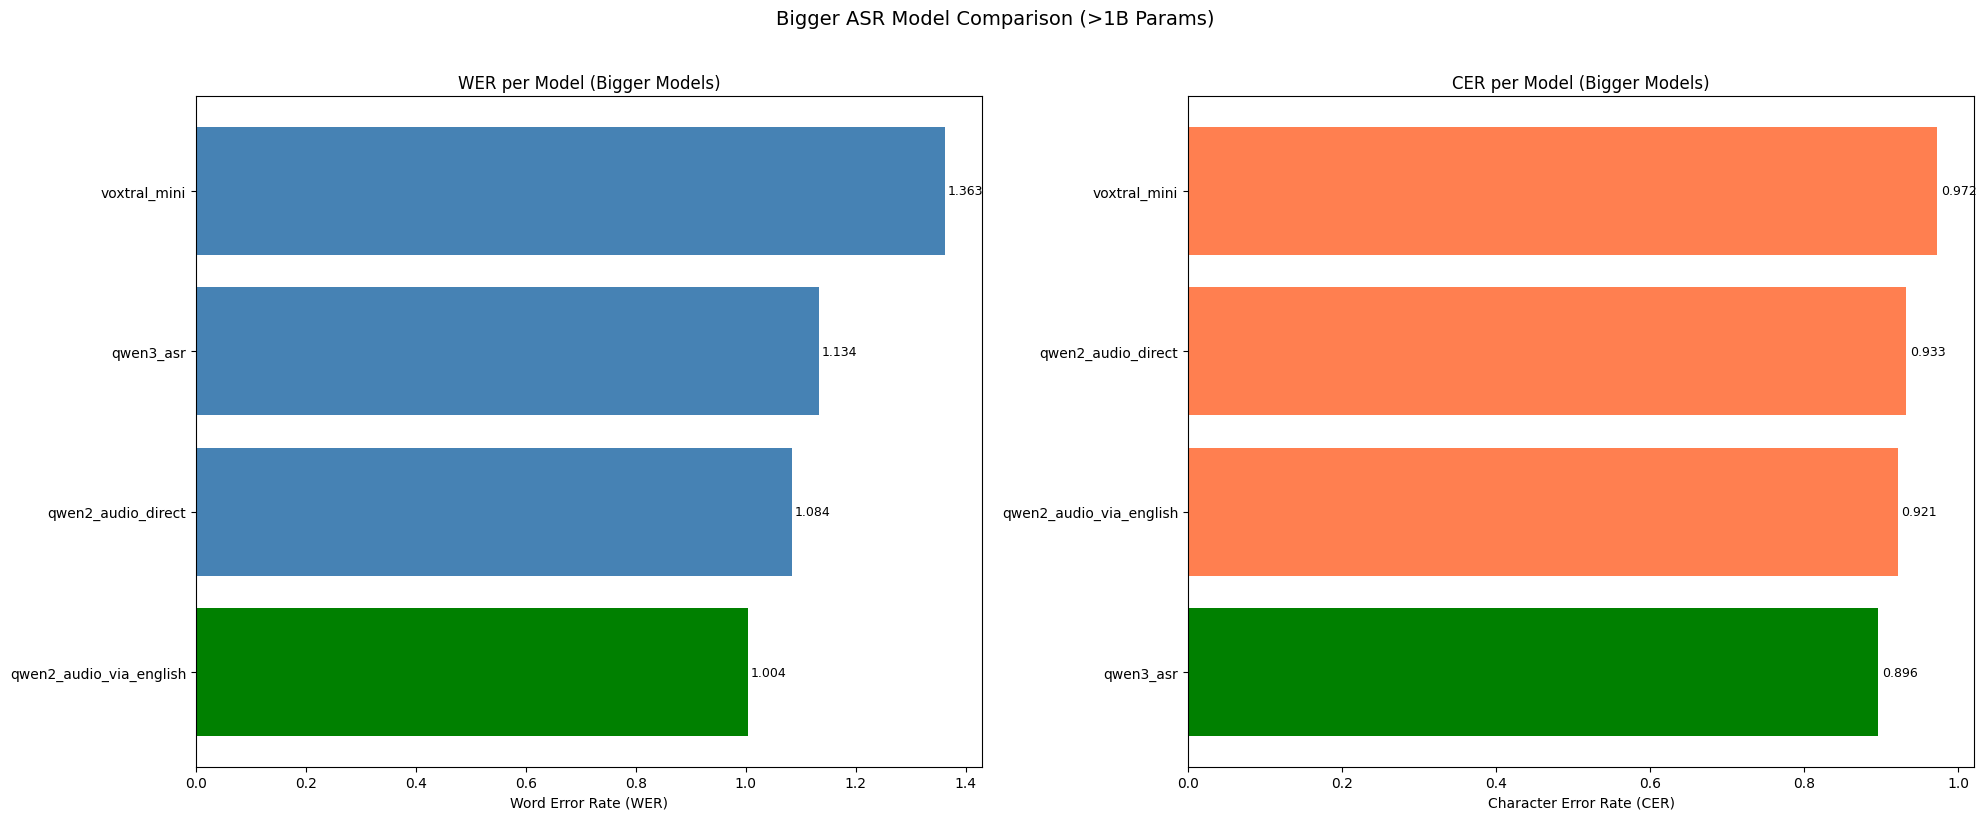

In [ ]:
import matplotlib.pyplot as plt

if df.empty:
    print('\u26A0  No data to plot.')
else:
    avg_by_model = df.groupby('model')[['wer', 'cer', 'mer', 'wil', 'wip', 'bleu']].mean()

    wer_data = avg_by_model['wer'].dropna().sort_values()
    cer_data = avg_by_model['cer'].dropna().sort_values()

    if len(wer_data) > 0 and len(cer_data) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

        colors_wer = ['green' if v == wer_data.min() else 'steelblue' for v in wer_data.values]
        ax1.barh(wer_data.index, wer_data.values, color=colors_wer)
        ax1.set_xlabel('Word Error Rate (WER)')
        ax1.set_title('WER per Model (Bigger Models)')
        for i, (model, v) in enumerate(wer_data.items()):
            ax1.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

        colors_cer = ['green' if v == cer_data.min() else 'coral' for v in cer_data.values]
        ax2.barh(cer_data.index, cer_data.values, color=colors_cer)
        ax2.set_xlabel('Character Error Rate (CER)')
        ax2.set_title('CER per Model (Bigger Models)')
        for i, (model, v) in enumerate(cer_data.items()):
            ax2.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

        fig.suptitle('Bigger ASR Model Comparison (>1B Params)', fontsize=14, y=1.02)
        plt.tight_layout()

        chart_path = f'{BIGGER_EVAL_DIR}/evaluation_charts_bigger.png'
        plt.savefig(chart_path, dpi=150, bbox_inches='tight')
        print(f'\u2705 Chart saved: {chart_path}')
        plt.show()
    else:
        print('\u26A0  No metric data to plot.')


---
## Dialect-Level Soft Accuracy
A transcription is considered "correct" if WER < 0.3. Per-model, per-dialect accuracy.
Saved as `bigger_models/dialect_accuracy_bigger.csv`.


In [ ]:
WER_THRESHOLD = 0.3

if df.empty:
    print('\u26A0  No data for accuracy calculation.')
else:
    dialect_rows = []
    for model_name in df['model'].unique():
        model_df = df[df['model'] == model_name].copy()
        row = {'model': model_name}
        overall_correct = 0
        overall_total   = 0
        for dialect in DIALECT_FOLDERS:
            d_df = model_df[model_df['dialect'] == dialect]
            has_wer  = d_df['wer'].notna()
            correct  = (d_df.loc[has_wer, 'wer'] < WER_THRESHOLD).sum()
            total    = has_wer.sum()
            accuracy = round(correct / total, 3) if total > 0 else None
            row[dialect] = accuracy
            overall_correct += correct
            overall_total   += total
        row['OVERALL'] = round(overall_correct / overall_total, 3) if overall_total > 0 else None
        dialect_rows.append(row)

    dialect_df = pd.DataFrame(dialect_rows).set_index('model')
    dialect_acc_path = os.path.join(BIGGER_EVAL_DIR, 'dialect_accuracy_bigger.csv')
    dialect_df.to_csv(dialect_acc_path)
    print(f'\u2705 Saved: {dialect_acc_path}')

    display_cols = DIALECT_FOLDERS + ['OVERALL']
    print('\n=== Dialect-Level Soft Accuracy (WER < 0.3 = correct) ===')
    print(dialect_df[display_cols].to_string())


✅ Saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/dialect_accuracy_bigger.csv

=== Dialect-Level Soft Accuracy (WER < 0.3 = correct) ===
                        puran_dhaka  barishal sylheti  normal_bangla  indian_bangla  OVERALL
model                                                                                       
qwen2_audio_direct             None       0.0    None            0.0            0.0      0.0
qwen2_audio_via_english        None       0.0    None            0.0            0.0      0.0
voxtral_mini                   None       0.0    None            0.0            0.0      0.0
phi4_multimodal                None       NaN    None            NaN            NaN      NaN
qwen3_asr                      None       0.0    None            0.0            0.0      0.0
qwen25_omni                    None       NaN    None            NaN            NaN      NaN


---
## Dialect-Level Confusion Matrix
Per-model correct/incorrect counts and WER heatmap per dialect.
Saved to `bigger_models/confusion_matrices/`.


✅ qwen2_audio_direct confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/confusion_matrices/qwen2_audio_direct_confusion.png


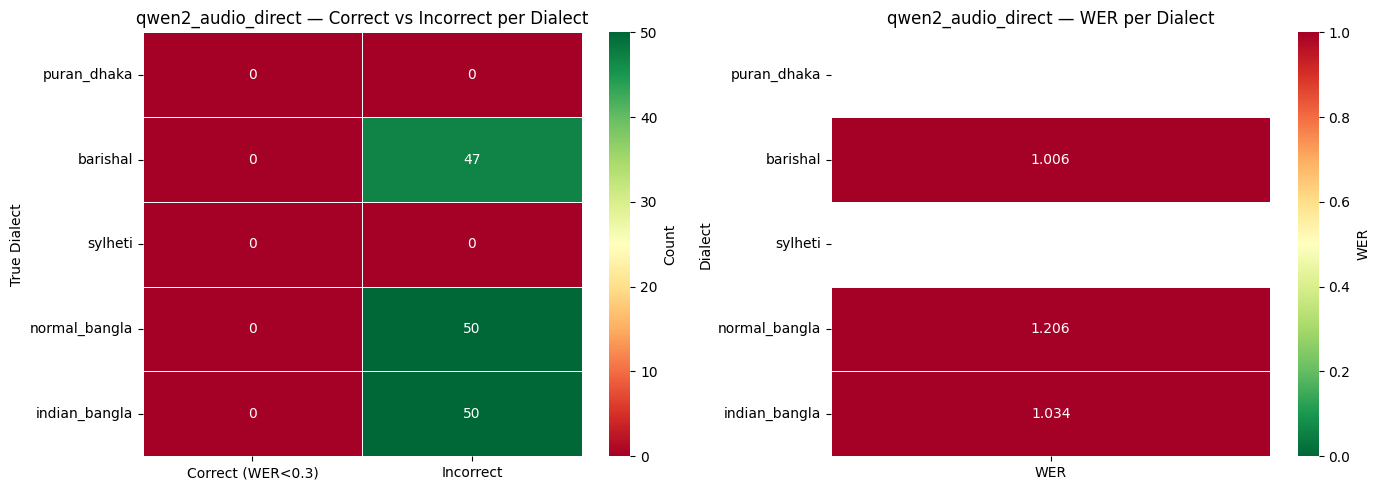

✅ qwen2_audio_via_english confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/confusion_matrices/qwen2_audio_via_english_confusion.png


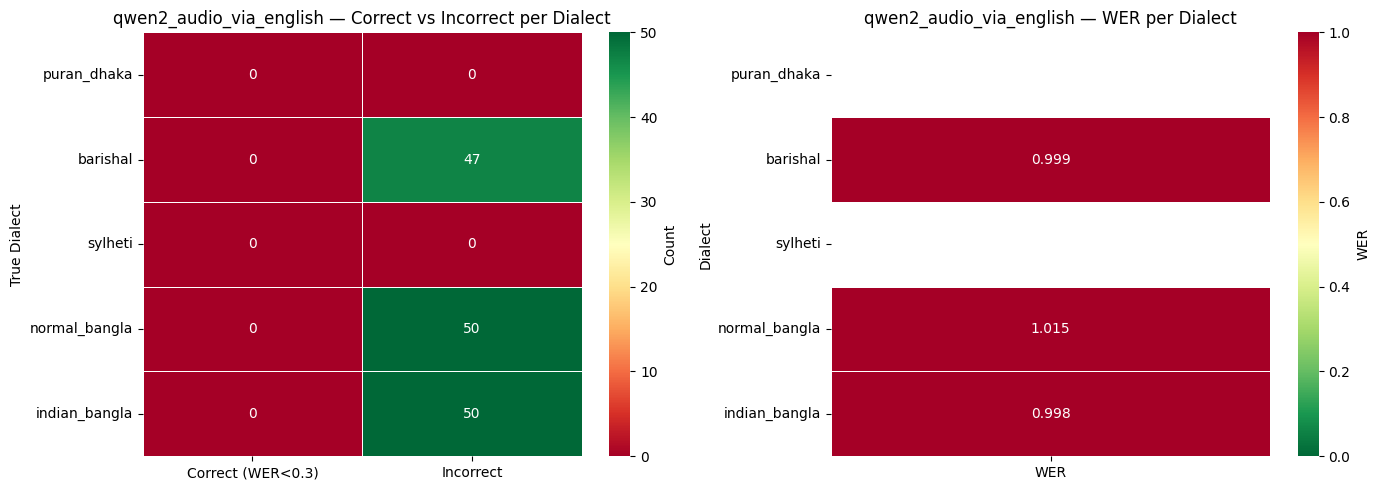

✅ voxtral_mini confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/confusion_matrices/voxtral_mini_confusion.png


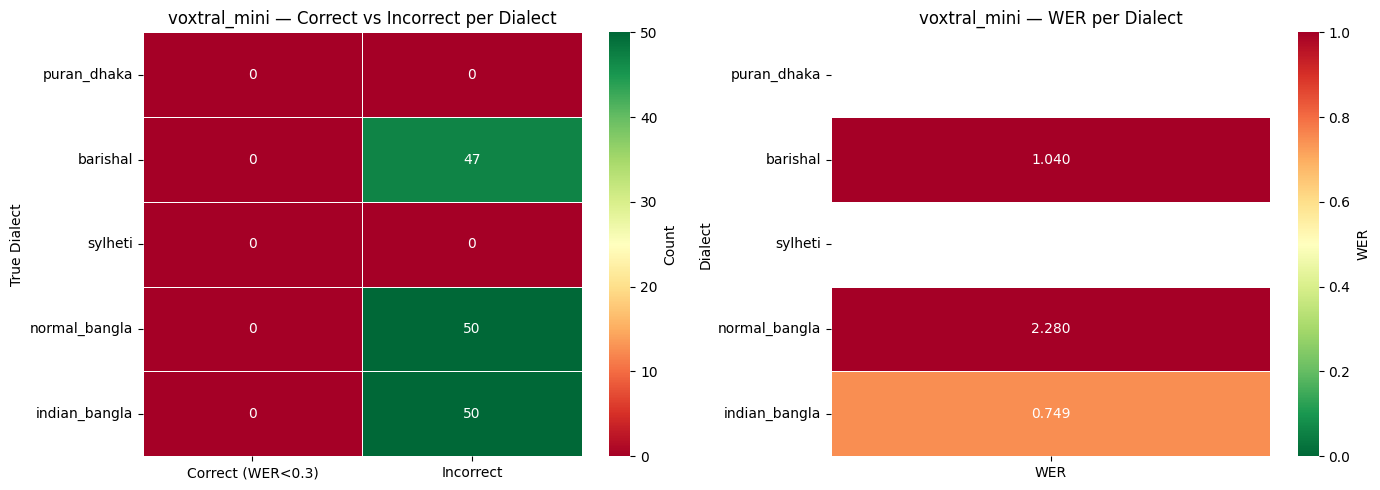

⏭  phi4_multimodal: No WER data — skipping confusion matrix.
✅ qwen3_asr confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/confusion_matrices/qwen3_asr_confusion.png


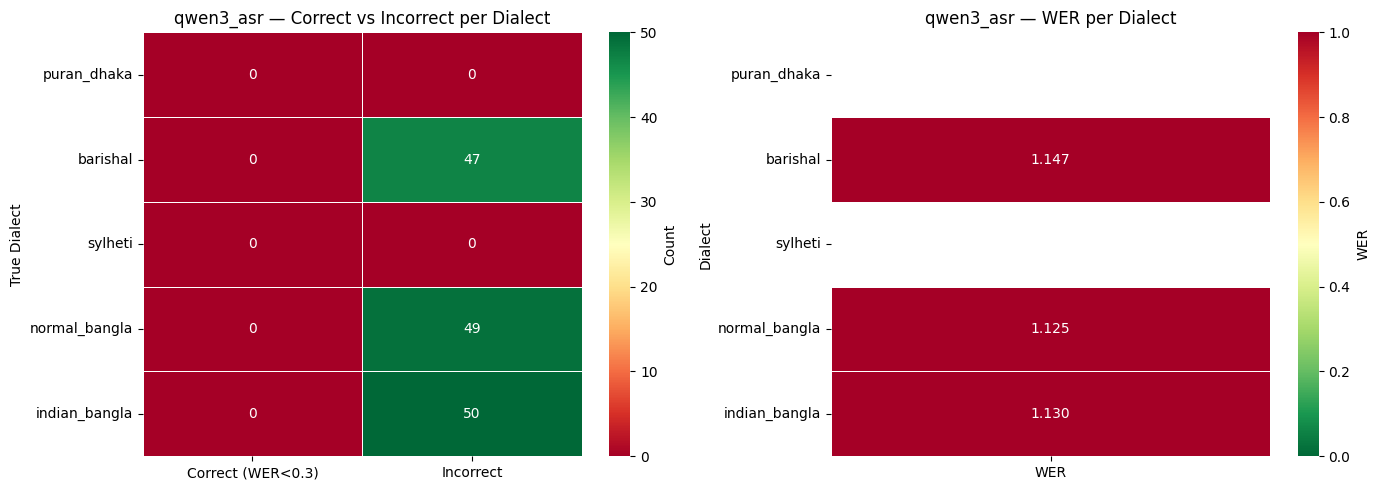

⏭  qwen25_omni: No WER data — skipping confusion matrix.

✅ All confusion matrices saved to: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/bigger_models/confusion_matrices/


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

SOFT_THRESHOLD = 0.3

if df.empty:
    print('\u26A0  No data for confusion matrices.')
else:
    os.makedirs(f'{BIGGER_EVAL_DIR}/confusion_matrices', exist_ok=True)

    for model_name in df['model'].unique():
        model_df = df[df['model'] == model_name]
        valid = model_df[model_df['wer'].notna()]
        if len(valid) == 0:
            print(f'\u23ED  {model_name}: No WER data \u2014 skipping confusion matrix.')
            continue

        matrix_data = {}
        for dialect in DIALECT_FOLDERS:
            dialect_valid = valid[valid['dialect'] == dialect]
            correct   = (dialect_valid['wer'] < SOFT_THRESHOLD).sum()
            incorrect = len(dialect_valid) - correct
            matrix_data[dialect] = {'Correct (WER<0.3)': correct, 'Incorrect': incorrect}

        matrix_df = pd.DataFrame(matrix_data).T
        matrix_df.index.name = 'Dialect'

        dialect_metrics = {}
        for dialect in DIALECT_FOLDERS:
            d_valid = valid[valid['dialect'] == dialect]
            if len(d_valid) > 0:
                dialect_metrics[dialect] = {
                    'WER': d_valid['wer'].mean(),
                    'CER': d_valid['cer'].mean() if 'cer' in d_valid else None,
                }
            else:
                dialect_metrics[dialect] = {'WER': None, 'CER': None}

        metrics_df = pd.DataFrame(dialect_metrics).T

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        sns.heatmap(matrix_df, annot=True, fmt='d', cmap='RdYlGn', ax=ax1,
                    linewidths=0.5, cbar_kws={'label': 'Count'})
        ax1.set_title(f'{model_name} \u2014 Correct vs Incorrect per Dialect')
        ax1.set_ylabel('True Dialect')

        wer_matrix = metrics_df[['WER']].astype(float)
        sns.heatmap(wer_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax2,
                    linewidths=0.5, cbar_kws={'label': 'WER'}, vmin=0, vmax=1)
        ax2.set_title(f'{model_name} \u2014 WER per Dialect')
        ax2.set_ylabel('Dialect')

        plt.tight_layout()
        cm_path = f'{BIGGER_EVAL_DIR}/confusion_matrices/{model_name}_confusion.png'
        plt.savefig(cm_path, dpi=150, bbox_inches='tight')
        print(f'\u2705 {model_name} confusion matrix saved: {cm_path}')
        plt.show()

    print(f'\n\u2705 All confusion matrices saved to: {BIGGER_EVAL_DIR}/confusion_matrices/')


---
## ✅ Complete

| Model | Params | Bengali | Status |
|---|---|---|---|
| qwen2_audio_direct | 7B | ⚠ Exp (8 langs) | **FIXED** — 4-bit quantization |
| qwen2_audio_via_english | 7B | ⚠ Exp | **FIXED** — 4-bit quantization |
| voxtral_mini | ~4.7B | ⚠ Exp (8 langs incl. Hindi) | **NEW** — replaces Canary-1B |
| phi4_multimodal | 5.6B | ⚠ Exp (8 langs) | **FIXED** — correct audio pipeline |
| qwen3_asr | 1.7B | ❌ None (30 langs) | **FIXED** — Hindi forced (closest language) |
| qwen25_omni | 7B | ⚠ Exp (19 langs) | **NEW** — replaces MiMo-Audio |
